# Dataset folder structure
```
data/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels/                                # txt files
	├── 0.txt
	.
	.
	.
	└── 1.txt
```

In [1]:
from pathlib import Path

MODEL='Kuzushiji'

EPOCHS=1

LR= 1e-4 #5e-6 

USE_CHECKPOINT = True

DATASET_PATH = Path('kaggle_kuzushiji')

DATASET_PATH.mkdir(parents=True, exist_ok=True)

PREPROCESS_DATA = False

AUGMENT_DATA = False

# Build lists of images and texts

In [2]:
import csv
if PREPROCESS_DATA:
    with open(DATASET_PATH / 'unicode_translation.csv', mode='r') as table:
        reader = csv.reader(table)
        unicode_to_transcription = dict((rows[0], rows[1]) for rows in reader)
        unicode_to_transcription['U+770C'] = '県'
        unicode_to_transcription['U+4FA1'] = '価'
        unicode_to_transcription['U+7A83'] = '窃'
        unicode_to_transcription['U+515A'] = '党'
        unicode_to_transcription['U+5E81'] = '庁'
        unicode_to_transcription['U+5039'] = '倹'
        
    with open(DATASET_PATH / 'train.csv', mode='r') as table:
        reader = csv.reader(table)
        images_to_labels = dict((rows[0], rows[1]) for rows in reader)
        del images_to_labels['image_id']

In [3]:
if PREPROCESS_DATA:
    data_dict = {}
    for id, label in images_to_labels.items():
        characters = label.split(' ')
        transcription = ''
        for i in range(len(characters)):
            if i % 5 == 0:
                transcription += unicode_to_transcription[characters[i]]
        data_dict['kaggle_kuzushiji/' + 'train_images/' + id + '.jpg'] = transcription
    print(list(data_dict.items())[0])

In [4]:
import json
from util.augmentation import augment_kuzushiji_kaggle
from util.data_processing import save_labels, split_dataset

if PREPROCESS_DATA:
    save_labels(data_dict, DATASET_PATH / 'labels.json')

with open(str(DATASET_PATH / 'labels.json'), 'r') as fp:
    data_dict = json.load(fp)

(DATASET_PATH/'train_images'/'augmented').mkdir(parents=True, exist_ok=True)
if AUGMENT_DATA:
    augment_kuzushiji_kaggle(data_dict, 3, 3, 3)
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

print(f"{len(data_dict.items())} dict elements")

word_files = list(data_dict.items())
print(word_files[0])

14420 dict elements
('kaggle_kuzushiji/train_images/100241706_00004_2.jpg', 'はがいけににの工こ三のやと己もさのの世細そ人けれだ強のたて俳根か諧れ子を及者ず避正文ふ時思なめ浮を気職老武楽も盲若自ど風に裏畳息序しし')


In [6]:
from util.data_processing import get_words_list


    
train_words = get_words_list(word_files)
print(f'Train size: {len(train_words)}')

Building dataset: 100%|██████████| 14420/14420 [00:02<00:00, 5261.26it/s]

Word(file_path='kaggle_kuzushiji/train_images/augmented/200021712-00028_2-0.jpg', transcription='一一はへへがへかのへのこのにかにとへににさるとにをてて玉ての仕ててににの火て火たにるにののて火の火又きよをの味くをを細のりを山ごとあぬりく右に吹りつ向と紅つ遣生任もまる卵にすも仕方ま紙こ方卵冷き紅卵しあき燕汁汁竹き方煎花よま卵脂時遠れ卵切熱卵趣湯煎し殻漬黄きげ漬しつ串貫しうく貫煎うしわし貫常煖ち卵ししし')
Train size: 14420


# Build dataset and dataloader

In [7]:
from util.data_processing import WORDSDataset
from dtrocr.config import DTrOCRConfig

config = DTrOCRConfig(max_position_embeddings=512
    # attn_implementation='flash_attention_2'
)
train_data = WORDSDataset(words=train_words, config=config)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
train_data[9]['labels'].shape

torch.Size([384])

In [9]:
import torch

mask = [False] * len(train_data.words)
i = 0
count = 0
for data in train_data:
    if data['labels'].shape != torch.Size([384]):
        count += 1
        print(i, count)
        mask[i] = True
    i += 1
        
print(count)

81 1
396 2
412 3
526 4
593 5
621 6
752 7
845 8
1008 9
1065 10
1073 11
1128 12
1351 13
1379 14
1457 15
1472 16
1632 17
1776 18
1876 19
1881 20
2441 21
2492 22
2501 23
2602 24
2680 25
2695 26
2729 27
2923 28
3131 29
3235 30
3244 31
3316 32
3865 33
4000 34
4025 35
4049 36
4103 37
4107 38
4315 39
4330 40
4483 41
5061 42
5215 43
5302 44
5385 45
5423 46
5564 47
5689 48
5775 49
5989 50
6122 51
6235 52
6378 53
6571 54
6794 55
6815 56
6893 57
6901 58
6963 59
6988 60
7023 61
7059 62
7367 63
7401 64
7489 65
7558 66
7845 67
7865 68
7950 69
8088 70
8121 71
8165 72
8199 73
8212 74
8240 75
8260 76
8386 77
8390 78
8484 79
8514 80
8830 81
8945 82
9127 83
9336 84
9579 85
9743 86
9795 87
9820 88
9825 89
10033 90
10048 91
10118 92
10122 93
10394 94
10995 95
11132 96
11197 97
11343 98
11710 99
12047 100
12444 101
12665 102
13008 103
13045 104
13462 105
13624 106
13860 107
13872 108
13918 109
14232 110
14296 111
14375 112
112


In [10]:
train_data.words = [a for i,a in enumerate(train_data.words) if not mask[i]]
len(train_data.words)

14308

In [11]:
from torch.utils.data import DataLoader
import multiprocessing as mp
from util.data_processing import WordsSampler

i = 0

if USE_CHECKPOINT and Path(f'{MODEL} train_samp_ind.txt').exists():
    with open(f'{MODEL} train_samp_ind.txt', 'r') as f:
        i = int(f.readline())
        print(i)
sampler = WordsSampler(train_data, i = i)
print(sampler.seq[0])


    

train_dataloader = DataLoader(train_data, batch_size=32, sampler=sampler, shuffle=False, num_workers=mp.cpu_count())

0


# Model

In [12]:
from util.model import get_model

model = get_model(config, MODEL)

# Training

In [13]:
from util.model import train

train(model, train_dataloader, None,  EPOCHS, MODEL, LR, 'Kkanji')

Epoch 1:   0%|          | 0/448 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLE

Epoch: 1 - Train loss: 6.1280171637024194, Train accuracy: 0.04520167283148372, Test loss: 0, Test accuracy: 0


In [14]:
list1, list2 = [0], [0]
print(list1[-1], list2[-1])

0 0


# Test

In [15]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
import torch
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/dtrocr-0.3.0-py3.12.egg/dtrocr/model.py:295: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)


Ответ:  一一はへへがへかのへのこのにかにとへににさるとにをてて玉ての仕ててににの火て火たにるにののて火の火又きよをの味くをを細のりを山ごとあぬりく右に吹りつ向と紅つ遣生任もまる卵にすも仕方ま紙こ方卵冷き紅卵しあき燕汁汁竹き方煎花よま卵脂時遠れ卵切熱卵趣湯煎し殻漬黄きげ漬しつ串貫しうく貫煎うしわし貫常煖ち卵ししし  Вывод модели:  一一はははははかかのかののののののののにののののにのににににににのにににににににににのにににをにをてをてをてててててててししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


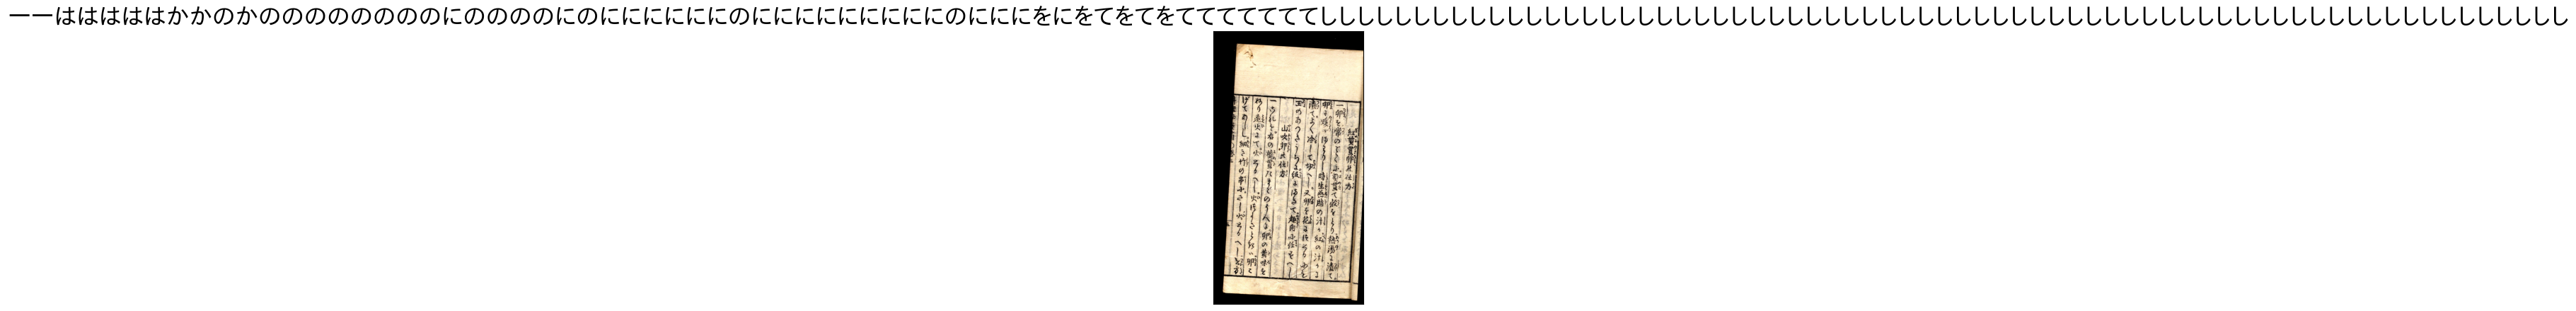

Ответ:  ニツへかはへツへか上かるツかンいがナへがへがたへこたツアかにかアのがたたイかたたやアたのるかてさけただたへしるアただのやをせやとりたアだ知んただ吉をくてめねそんらとたて出や己て己出りませきもにららしだふししりとらやつに人もそめでもた物ひりまでで処たで久大様ももにら火あだもちど子んけ些ん打ま出朝何しれ腹てじしれつて言様往誠あ鉢処左往し傍捨呉自姉言何を勿屋ううり往暇居して居自金け過遣来事立着き当弾借今論無ま帯些置  Вывод модели:  ははははははははははははははははのはののののののののののののののののののののののにののにののににににのににににににににににににににににににににににににににににににもももにももににももももももももしももももししししししししししししししししししししししししし


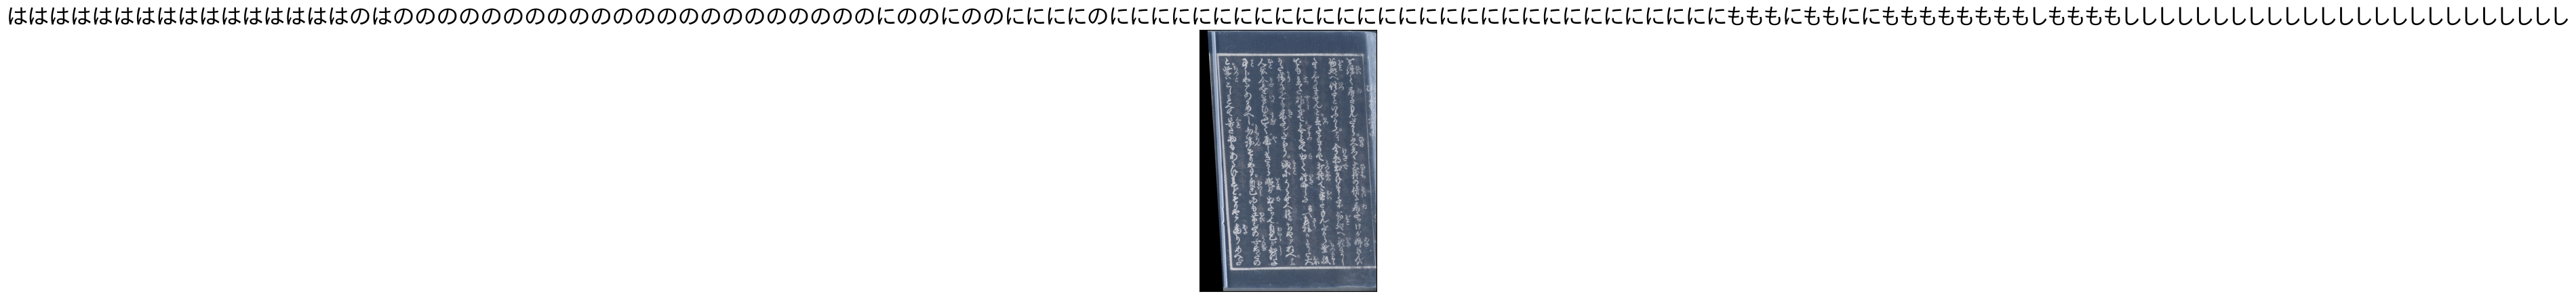

Ответ:  四は八かい十傾と城す手買00目000総しし手るれ手手手ぽ手たりす見のそつんたやしぬ〱  Вывод модели:  一ははははははははははかかかののののののののののののののののののののののののののののののののをにををのををのををのををををしをてをしをしししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


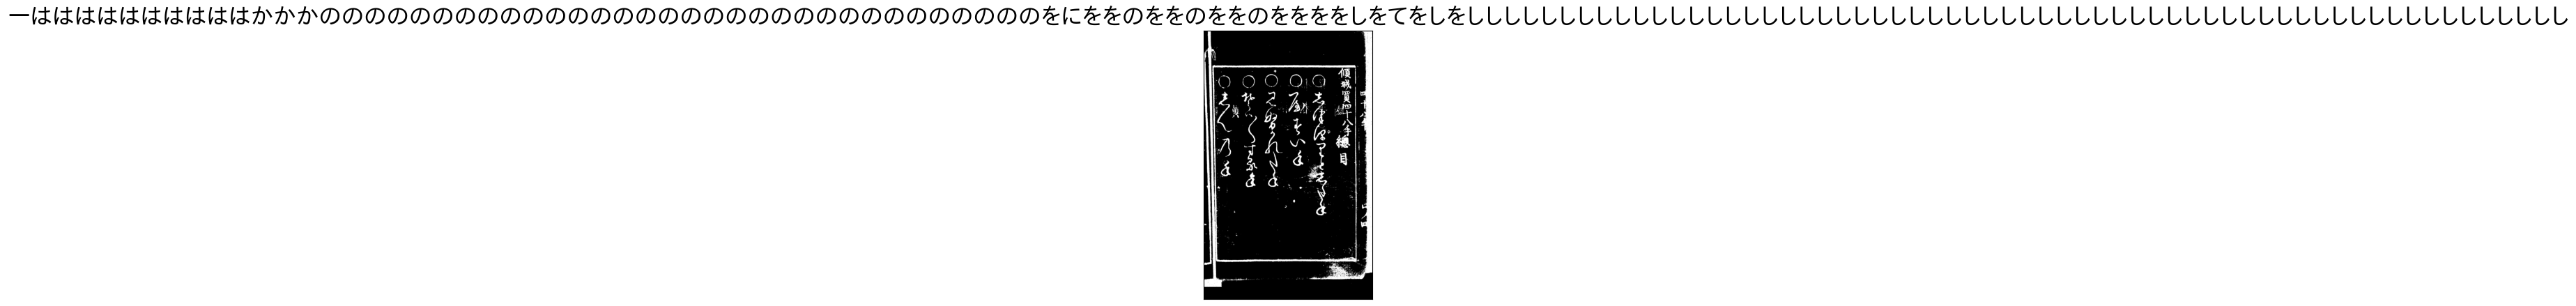

Ответ:  一へへ八がのおやのをるをののに八五おををか目をのを百○十もろの○切や入りざひさせ込○うり本りもま十○入るるあぬ柚せ早したゆ上すふ品大ろで玉か半砂に天りば卵氷に団りけ白天右卵柚のく間為味扨煉り能溜砂氷な至中鶏うたず流す器扇んに去斗詰べくな漉り身黄糖斗能糖置て斗卵類してりてばな鶏うてぎな角置て白鶏して皮て角しては青なしし香しし煮篩羹薫蓋し  Вывод модели:  一一はははのののののののののののののののののののののののののてにててのててしててししてしししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


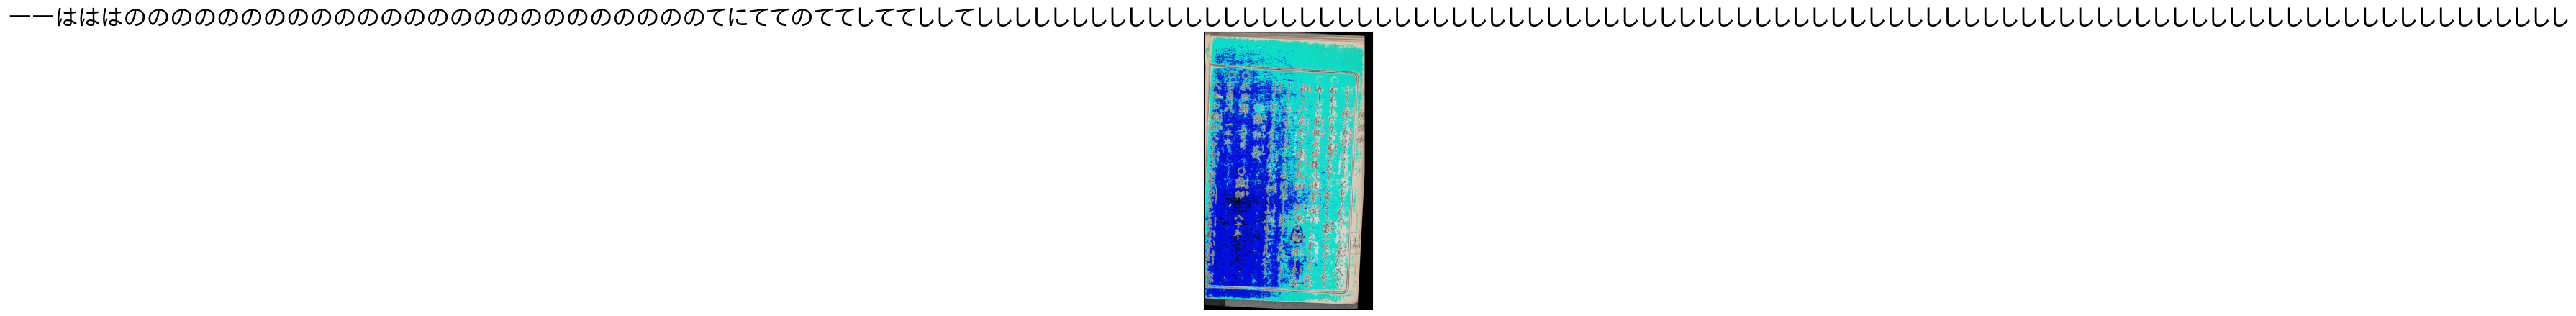

Ответ:  ははかかがやか二へわにせよるの入出切るべに日にをたゆなくよによゆよくてよそてほりら田り山物吸な山ゆて時りなに仕うす沢ばくし用沢ん用で小柚味拵分し随噌漬し楽前盛鰹たて計水べしし倉ししし汁  Вывод модели:  一一ははかかにににににににににににににににににににににににににににてにてててててててててててしてししてしししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


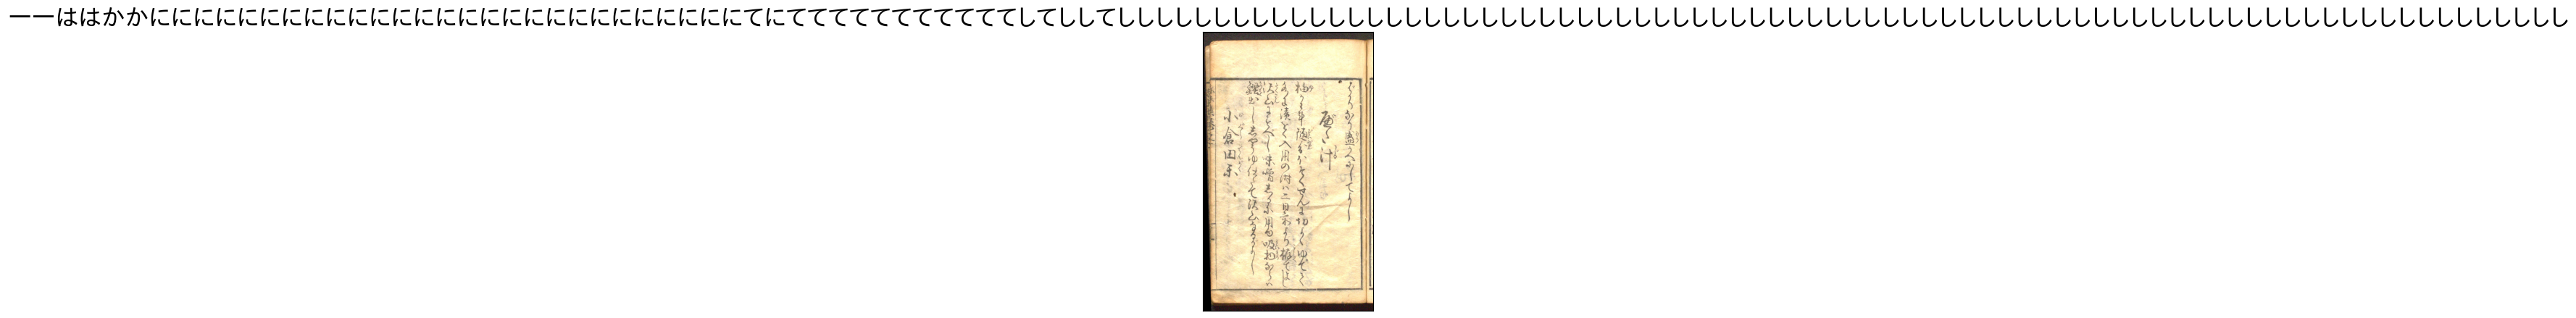

Ответ:  一七十ゝ九かかかかい候五い五五候分ふるはめるをとに候せふとはせまのほにつろににさにのさは右を切に切たてにや合のやのにあの合やひ粉はうてのさあ残む上斗きすうくすのむ合つ能壱のん申沙け白少うけつ粉餅す方て馬申ろ糖も升をらち粉う有米しん能餅しりひ様きしりしし  Вывод модели:  一一はははははかのののののののののののにのののにのののにのにににににににににににててててててててししてしししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


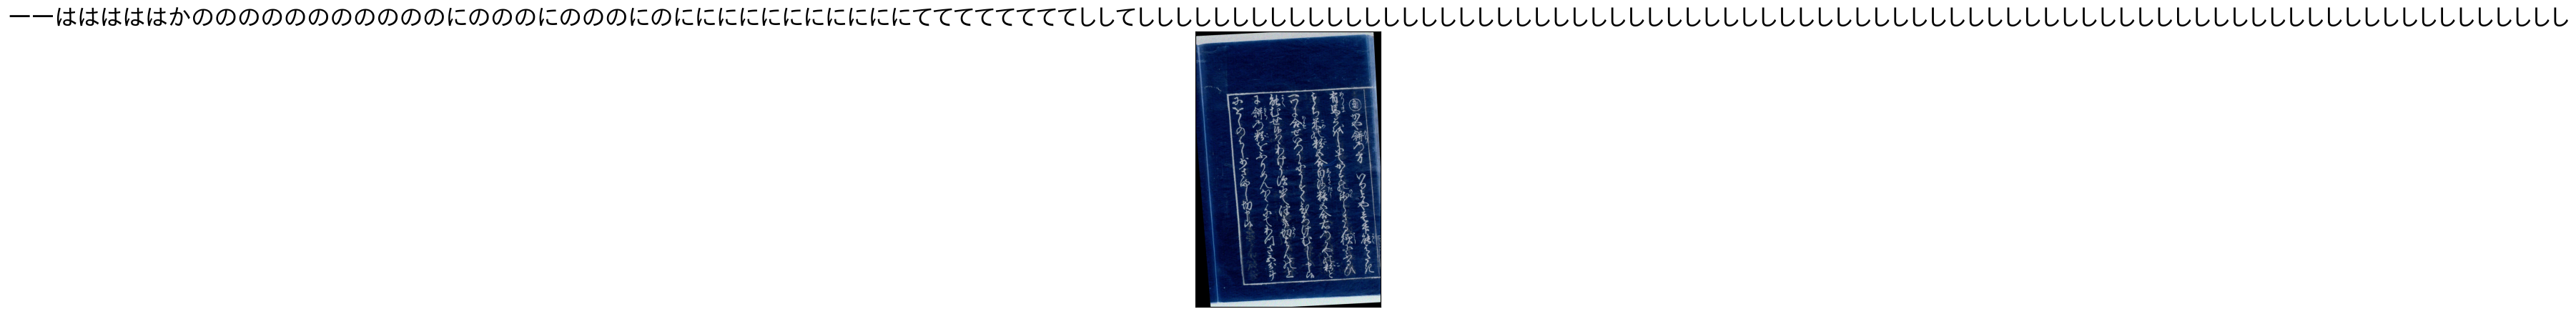

Ответ:  一いははははいいばいい口かかいかい出いか三へやよみかにくま候よふせふさ能候り又ににのに入つのまゆ右さにをのたのをにを物にりひに白もな子よきておる候何あきときに味りすやたにををつた分すを杉けに山ろもつまてろりび鯛たみを吉もて伊くくだの豆のき箱わ玉びみだすてりしきうけろそてれりりも噌てりてくどすだし鯛うりすてししうしくたし勢葛也鮒き置〱又腐ししし葛鳥申し布しし〱事  Вывод модели:  一ははははははははははかかかかかののののののののののののののののののののにににのにののにののににににののににのにのにのののににのにににににににににににににににににににににににににににににににににしにしにしししししししししししししししししししししししししし


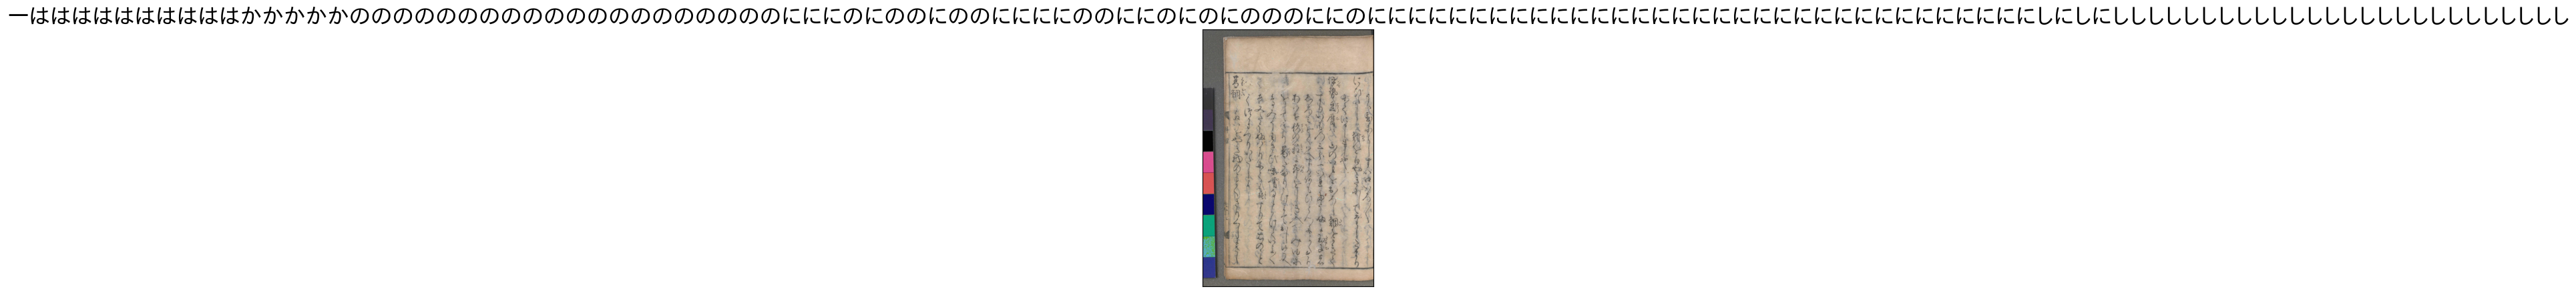

Ответ:  はははかかへか云かへかはにらかかごともがををらこ物ごび但ふてく物と但のさ又ふ妊とらわ又ゆゆわふ金て○ふこらびきき或又びすわ産食食水び又産す後葉虚瘡ん胃脾す人う食食葉す婦婦し  Вывод модели:  一ははははかかののののののののののののにののにのににににのにににのにににににににててててててててしててしてしししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


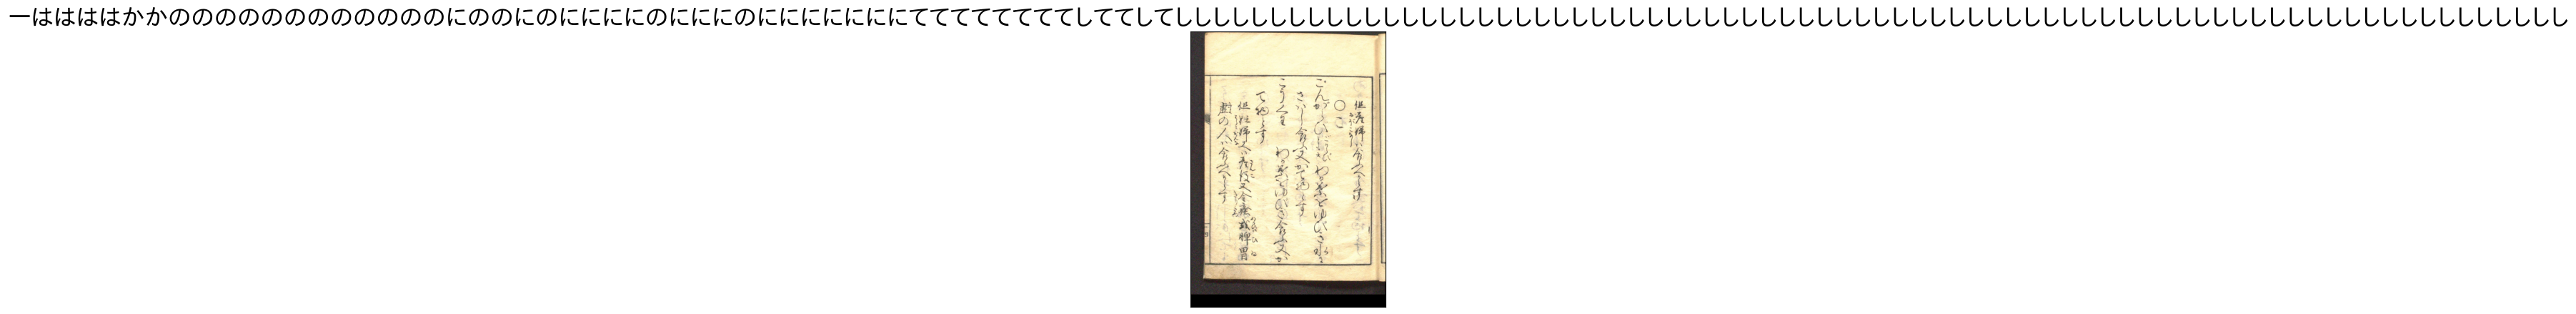

Ответ:  メ丁六同同同ヲ同ウウ物松里吸豆れ狭早鮓隠鮓腐若盛鉾蒲菜茸  Вывод модели:  一一ははかかかのののののののにのににのににににににににににににににににてててにてててててててててししてしししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししししし


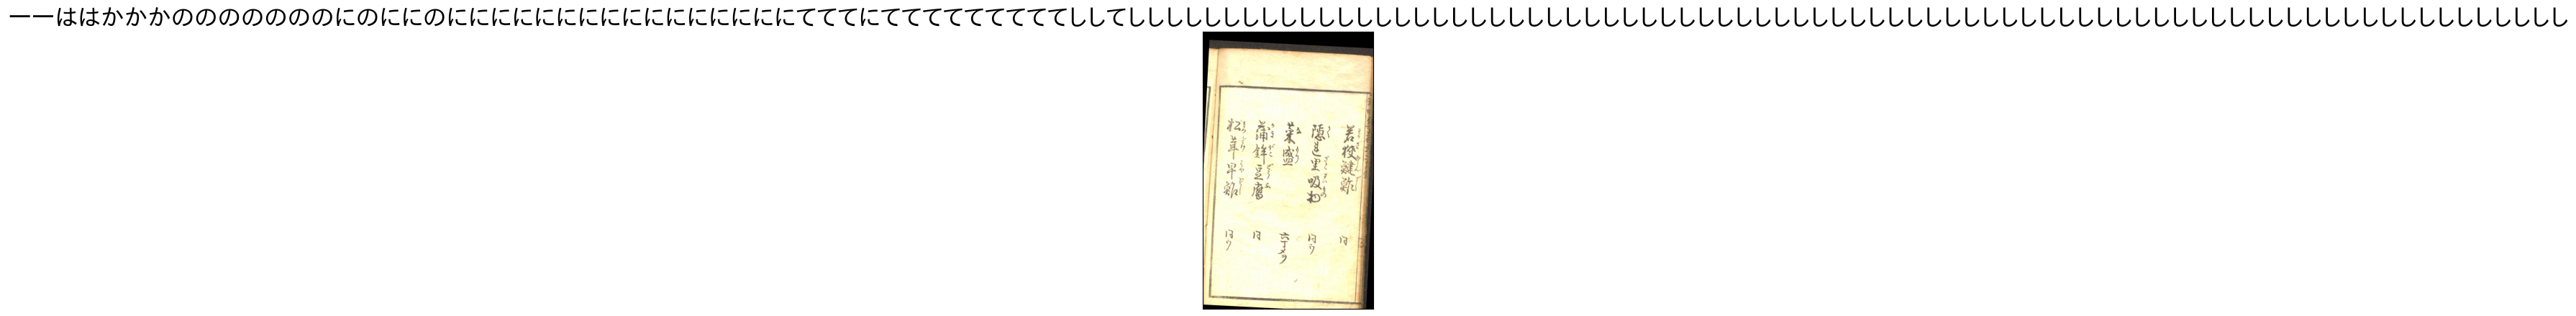

Ответ:  一一ゝゝゝゞはか々はへべべばかへか二ははかはへかばかこはへのやいのたのこるのトるがにば也やるめがののる候ばつしくかがのふ八こ候けおくるじにじるい田三ししかせせにをゐふ八よたてそをくとににつ小しみわれとにににめて且士をきしとけのに九くよくりよりとららとをけんををを他りもた回十ぞ将くにとに且とられそ臣き処ら給しててしりと白由そて子をで人もと主蛇攻人まとなやね推り内西得太下折り區国両る入しうはとも里問迂ぼ人人れあ至ぞ立又く開ば父堀名悔相を杉とまなな只き吟願てて生そずろを路沈個てれら結申ずすを傾安信見告程死見総終膝佶何推も里連てりてすず当頓頭必従犬時び老趣没論うし参討之僅し其来伝告近て見渡な身来気遠俟模浦南離色眉郎打頻海浜総倉余者し年連議城衆障実時基来辤巻事廊後し景見遽滝参変遶景着武伝負潰禁草窺季黨尋義落落意驚  Вывод модели:  へはははははははははははははははのはののののののののののののののののののののののののののののににににのににににににににににににににににににもににににもにもにももももももももももももももももももももももももももももももももももももしもももももももししししし


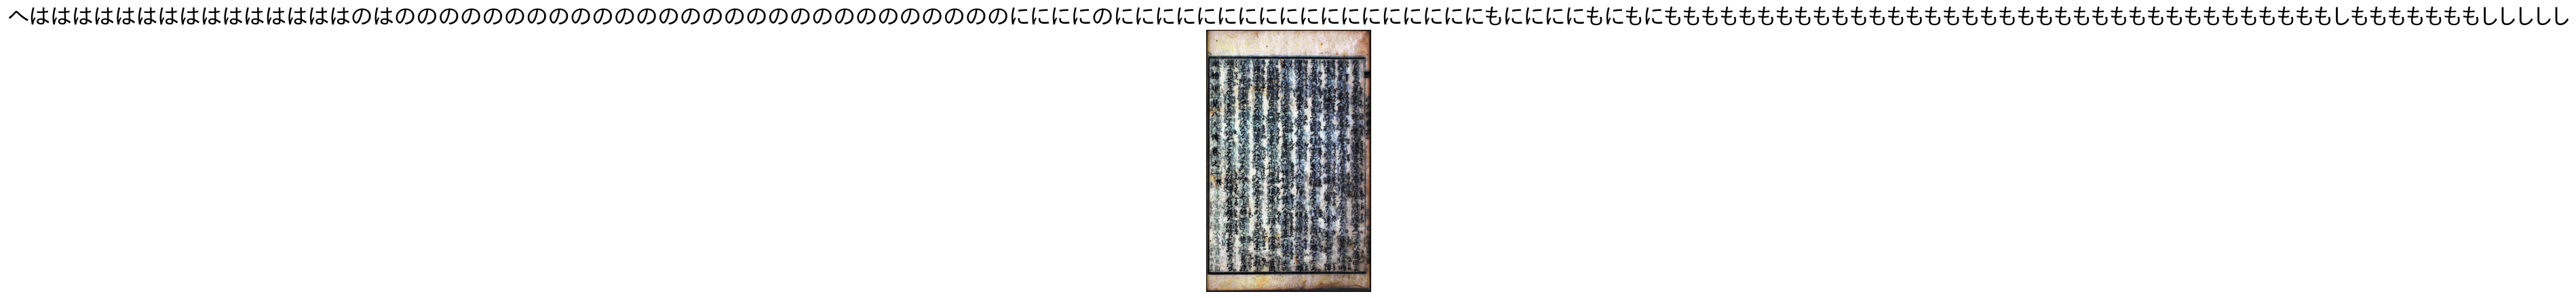

In [16]:
from util.model import test

test(model, train_words, 10)